# 19 · Sparse matrices and 2D PDEs at realistic size

**Problem.** A 2 W chip (20 × 20 mm) sits at the centre of a 100 × 60 mm circuit board, 1.6 mm thick,
whose edges are clamped to a heat-sinking frame at 25 °C. Copper planes give the board an effective
in-plane conductivity of about 20 W/(m·K). How hot does the board get? Steady conduction with a heat
source is the **Poisson equation**
$$-\nabla^2 T = \frac{\dot q}{k},\qquad \dot q = \frac{P}{A_{chip}\,t}\ \text{under the chip, 0 elsewhere}.$$
A grid fine enough to resolve the chip has tens of thousands of unknowns - far too many for dense
matrices, easy with **sparse** ones.

**What you will learn**

- discretise a 2D Poisson problem with the 5-point stencil
- build and store sparse matrices with Kronecker products
- solve large systems with sparse direct solvers and conjugate gradient
- check grid independence and simulate a transient with a reused factorisation

**Before you start:** notebooks 03, 12 and 15; partial derivatives  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
import time
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from engmath import sparse

In [2]:
Lx, Ly, thick, kb, P, T_edge = 0.100, 0.060, 1.6e-3, 20.0, 2.0, 25.0
q_vol = P / (0.02 * 0.02 * thick)                            # W/m3 under the chip
def source(x, y):                                            # right-hand side q/k
    chip = (np.abs(x - Lx/2) <= 0.01) & (np.abs(y - Ly/2) <= 0.01)
    return np.where(chip, q_vol / kb, 0.0)

nx, ny = 299, 179                                            # interior nodes: dx = dy = 1/3 mm
N = nx * ny
A = sparse.laplacian_2d(nx, ny, Lx/(nx + 1), Ly/(ny + 1))
print(f"unknowns: {N:,}")
print(f"nonzeros: {A.nnz:,} ({A.nnz/N:.2f} per row)")
print(f"memory as a sparse matrix: {(A.data.nbytes + A.indices.nbytes + A.indptr.nbytes)/1e6:.1f} MB")
print(f"memory as a dense matrix:  {N**2 * 8 / 1e9:.1f} GB")

unknowns: 53,521
nonzeros: 266,649 (4.98 per row)
memory as a sparse matrix: 3.4 MB
memory as a dense matrix:  22.9 GB


Each row has at most five nonzeros (a node and its four neighbours), so storing only those - a
**sparse** matrix - needs a few megabytes instead of tens of gigabytes. The pattern for a tiny 6 × 4 grid:

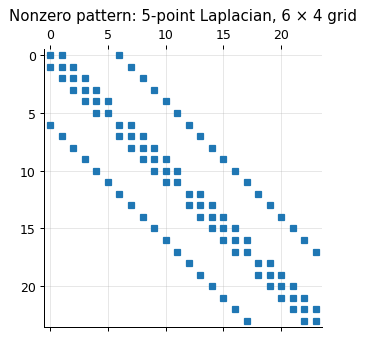

In [3]:
small = sparse.laplacian_2d(6, 4, 1.0, 1.0)
plt.figure(figsize=(4, 4)); plt.spy(small, markersize=5)
plt.title("Nonzero pattern: 5-point Laplacian, 6 × 4 grid"); plt.show()

## Inside the algorithm: the 2D Laplacian from Kronecker products
Number the grid nodes row by row. The 2D operator is the 1D operator acting along $x$ in every row plus
the 1D operator acting along $y$ in every column: $A = I_y \otimes T_x + T_y \otimes I_x$. For a 3 × 2 grid:

In [4]:
Tx = sparse.laplacian_1d(3, 1.0).toarray()
Ty = sparse.laplacian_1d(2, 1.0).toarray()
print((np.kron(np.eye(2), Tx) + np.kron(Ty, np.eye(3))).astype(int))

[[ 4 -1  0 -1  0  0]
 [-1  4 -1  0 -1  0]
 [ 0 -1  4  0  0 -1]
 [-1  0  0  4 -1  0]
 [ 0 -1  0 -1  4 -1]
 [ 0  0 -1  0 -1  4]]


## Solving at realistic size

sparse direct (LU): 0.27 s;  conjugate gradient: 0.36 s;  max difference 4.4e-10 K
maximum board temperature: 41.8 °C


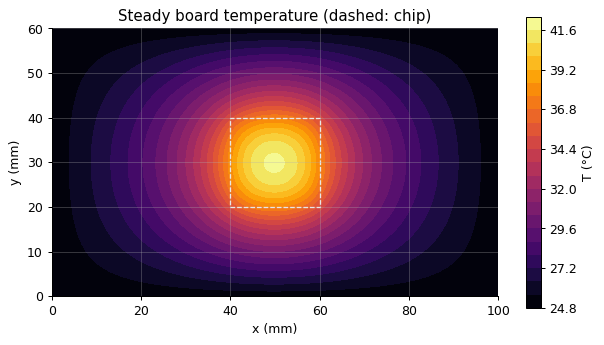

In [5]:
t0 = time.perf_counter()
X, Y, T = sparse.poisson_dirichlet(source, lambda x, y: T_edge + 0*x, Lx, Ly, nx, ny)
t_direct = time.perf_counter() - t0
t0 = time.perf_counter()
_, _, T_cg = sparse.poisson_dirichlet(source, lambda x, y: T_edge + 0*x, Lx, Ly, nx, ny, solver="cg")
t_cg = time.perf_counter() - t0
print(f"sparse direct (LU): {t_direct:.2f} s;  conjugate gradient: {t_cg:.2f} s;  "
      f"max difference {np.max(np.abs(T - T_cg)):.1e} K")
print(f"maximum board temperature: {T.max():.1f} °C")
fig, ax = plt.subplots(figsize=(8, 4.2))
cs = ax.contourf(X*1000, Y*1000, T, levels=20, cmap="inferno")
fig.colorbar(cs, label="T (°C)")
ax.add_patch(plt.Rectangle((40, 20), 20, 20, fill=False, ec="w", ls="--"))
ax.set(aspect="equal", xlabel="x (mm)", ylabel="y (mm)", title="Steady board temperature (dashed: chip)")
plt.show()

How does conjugate gradient converge? Each iteration needs only one sparse matrix-vector product, but
the number of iterations grows with the grid size:

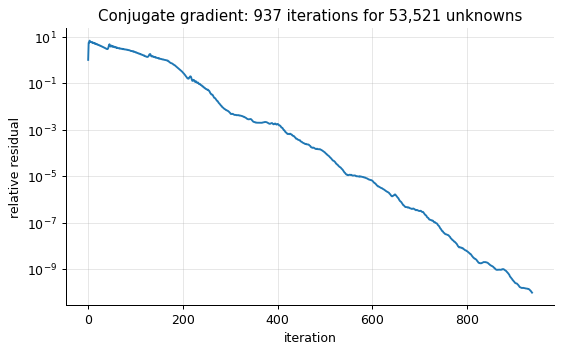

In [6]:
rhs = source(X[1:-1, 1:-1], Y[1:-1, 1:-1]).ravel()
_, hist = sparse.conjugate_gradient(A, rhs, tol=1e-10)
plt.semilogy(hist); plt.xlabel("iteration"); plt.ylabel("relative residual")
plt.title(f"Conjugate gradient: {len(hist) - 1} iterations for {N:,} unknowns"); plt.show()

For comparison, Gauss-Seidel (notebook 03) needs a number of sweeps that grows with the *square* of the
number of nodes across the board - hundreds of thousands of sweeps here. Sparse direct solvers and
Krylov methods such as CG (usually with a *preconditioner*) are what engineering software uses.

## Is the grid fine enough?

In [7]:
for n_x, n_y in ((99, 59), (199, 119), (299, 179)):
    _, _, Tg = sparse.poisson_dirichlet(source, lambda x, y: T_edge + 0*x, Lx, Ly, n_x, n_y)
    print(f"grid {n_x + 1:>3} × {n_y + 1:<3} (spacing {Lx/(n_x + 1)*1000:.2f} mm): max T = {Tg.max():.3f} °C")

grid 100 × 60  (spacing 1.00 mm): max T = 41.778 °C
grid 200 × 120 (spacing 0.50 mm): max T = 41.781 °C


grid 300 × 180 (spacing 0.33 mm): max T = 41.782 °C


The maximum temperature changes little between the two finer grids: the answer is grid-independent to
the accuracy an engineer needs.

## Transient heating after switch-on
With heat capacity, $\rho c\,\partial T/\partial t = k\nabla^2 T + \dot q$. Implicit (backward) Euler in time -
unconditionally stable (notebooks 11 and 12) - needs one sparse solve per step with the *same*
matrix $I + \Delta t\,\alpha A$, so it is factorised once and reused. With $\theta = T - 25$ °C the edges are
at $\theta = 0$:

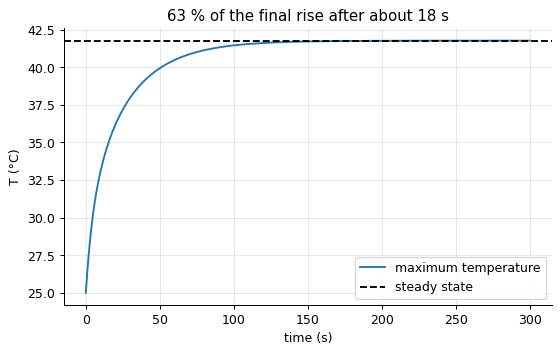

In [8]:
rho_c = 1900 * 1100                                         # J/(m3 K), typical board
alpha = kb / rho_c
nxt, nyt = 99, 59
At = sparse.laplacian_2d(nxt, nyt, Lx/(nxt + 1), Ly/(nyt + 1))
Xt, Yt = np.meshgrid(np.linspace(0, Lx, nxt + 2)[1:-1], np.linspace(0, Ly, nyt + 2)[1:-1])
ft = source(Xt, Yt).ravel()
dt, t_end = 1.0, 300.0
lu = spla.splu((sps.identity(nxt*nyt, format="csc") + dt * alpha * At).tocsc())   # factorise once
theta = np.zeros(nxt * nyt)
times, Tmax = [0.0], [T_edge]
for step in range(int(t_end / dt)):
    theta = lu.solve(theta + dt * alpha * ft)
    times.append((step + 1) * dt); Tmax.append(T_edge + theta.max())
theta_ss = spla.spsolve(At.tocsc(), ft)
t63 = times[np.argmax(np.array(Tmax) - T_edge >= 0.632 * theta_ss.max())]
plt.plot(times, Tmax, label="maximum temperature")
plt.axhline(T_edge + theta_ss.max(), color="k", ls="--", label="steady state")
plt.xlabel("time (s)"); plt.ylabel("T (°C)"); plt.legend(); plt.title(f"63 % of the final rise after about {t63:.0f} s")
plt.show()

## Exercises
1. The board also loses heat from both faces by convection, $h$ = 10 W/(m²·K). This adds a term
   $(2h/(k\,t))\,\theta$ to the equation, i.e. $A \to A + \frac{2h}{k t} I$. How much does the peak temperature drop?
2. Time the direct solver for grids of 100², 200², 400² and 800² nodes (if memory allows). How does the
   time grow with the number of unknowns?
3. Is the 63 % time accurate? Repeat the transient with time steps of 2 s and 0.5 s. How large is the
   time-step error of backward Euler here, and how does it scale with the step?
4. **Implement it yourself:** add a Jacobi preconditioner to `conjugate_gradient` (divide the residual by the diagonal of $A$ when forming the search direction). How many iterations does it save for the board problem? Why so few, for this particular matrix?